<a href="https://colab.research.google.com/github/muhammadnaufalpratama53-eng/Nama-data-wrangling-tugas1-Public/blob/main/Tugas_Data_wrangling_naufal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [2]:
from google.colab import files
uploaded = files.upload()

Saving data_iklim - Sheet1.csv to data_iklim - Sheet1 (1).csv


Pertama. kita mengupload data, dalam kasus ini "data_iklim - Sheet1 (1).csv

In [5]:
df = pd.read_csv("data_iklim - Sheet1 (1).csv")
df.head()

,precipitation,max temperature,min temperature,wind,relative humidity,solar
0,"22,17864727","22,579","16,226","0,98477418","0,949216707","12,98674041"
1,"10,77861942","29,369","20,2985","1,054619598","0,837694214","20,63957504"
2,"9,443091888","27,384","18,62","0,999835774","0,869631027","18,48553254"
3,"15,51303961","21,7585","14,9085","0,922273123","0,95195662","9,497525996"
4,"15,21262902","24,568","17,651","1,078517568","0,927156092","15,35485704"


Kemudian membuat loop yang mengecek apakah ada file string di dalam.
lalu pemanggilan sns untuk membuat heatmap dan kemudian menampilkannya dalam matplotlib

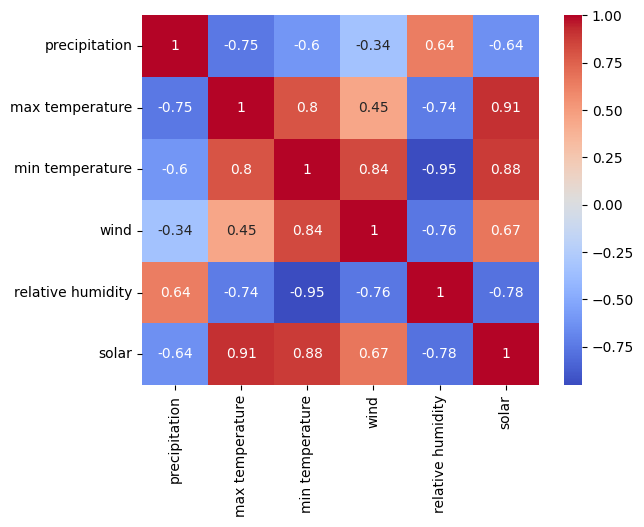

In [9]:
for col in df.columns:
    if df[col].dtype == 'object': # Check if the column is of object type (likely strings)
        df[col] = df[col].str.replace(',', '.', regex=False).astype(float)

corr = df.corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

Membuat variable X dan Y menggunakan pandas. lalu membuat variabel model dan menampilkan summary

In [10]:
X = df[['max temperature','min temperature','wind','relative humidity','solar']]
Y = df['precipitation']

X = sm.add_constant(X)

model = sm.OLS(Y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          precipitation   R-squared:                       0.658
Model:                            OLS   Adj. R-squared:                  0.634
Method:                 Least Squares   F-statistic:                     27.72
Date:                Mon, 09 Mar 2026   Prob (F-statistic):           1.55e-15
Time:                        03:46:42   Log-Likelihood:                -164.19
No. Observations:                  78   AIC:                             340.4
Df Residuals:                      72   BIC:                             354.5
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -8.9870     16.48

Memanggil sns historic plot

<Axes: ylabel='Count'>

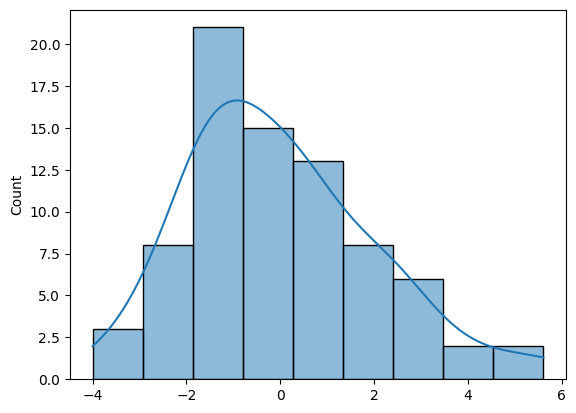

In [11]:
sns.histplot(model.resid, kde=True)

pemanggilan plot scatter

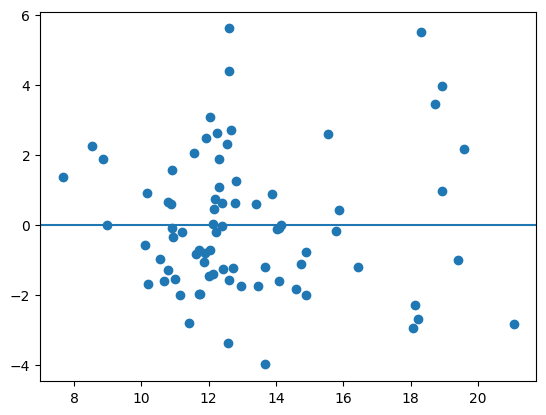

In [13]:
plt.scatter(model.fittedvalues, model.resid)
plt.axhline(0)